In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# ── STEP 1: DATA LOAD ────────────────────────────────────────────────────────

try:
    df = pd.read_csv('../data/train.csv', encoding='latin1')
    print("Data loaded successfully!")
except FileNotFoundError:
    print("train.csv not found")
    exit()

df.rename(columns={'Order Date': 'date', 'Sales': 'sales'}, inplace=True)
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date').dropna().reset_index(drop=True)

df["Month"]     = df["date"].dt.month
df["Year"]      = df["date"].dt.year
df["DayOfWeek"] = df["date"].dt.dayofweek
df["DayOfYear"] = df["date"].dt.dayofyear
df["Quarter"]   = df["date"].dt.quarter

print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(df[['date', 'sales', 'Month', 'Year', 'DayOfWeek']].head())
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nClean data ready — Total rows: {len(df)}")

high_sales     = [round(s, 2) for s in df['sales'] if s > 1000]
category_count = {c: int(n) for c, n in df['Category'].value_counts().items()}
print(f"\nOrders above $1000: {len(high_sales)}")
print(f"Orders per Category: {category_count}")

Data loaded successfully!
Rows: 9789  |  Columns: 23
Date range: 2015-01-03 to 2018-12-30
        date    sales  Month  Year  DayOfWeek
0 2015-01-03   16.448      1  2015          5
1 2015-01-04    3.540      1  2015          6
2 2015-01-04  272.736      1  2015          6
3 2015-01-04   11.784      1  2015          6
4 2015-01-05   19.536      1  2015          0

Missing values:
Row ID           0
Order ID         0
date             0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
sales            0
Month            0
Year             0
DayOfWeek        0
DayOfYear        0
Quarter          0
dtype: int64

Clean data ready — Total rows: 9789

Orders above $1000: 459
Orders per Category: {'Office Supplies': 5903, 'Furniture': 2076, 'Technology': 1810}


In [5]:
# ── STEP 2: DAILY AGGREGATION + LAG FEATURES ─────────────────────────────────

dd = df.groupby('date')['sales'].sum().reset_index().sort_values('date').reset_index(drop=True)

for col, fn in [('Month','month'), ('Year','year'), ('DayOfWeek','dayofweek'),
                ('DayOfYear','dayofyear'), ('Quarter','quarter')]:
    dd[col] = getattr(dd['date'].dt, fn)

dd['Lag1']  = dd['sales'].shift(1)
dd['Lag7']  = dd['sales'].shift(7)
dd['MA7']   = dd['sales'].rolling(7).mean()
dd['Trend'] = dd['sales'].rolling(30, center=True).mean()
dd.dropna(inplace=True)
dd.reset_index(drop=True, inplace=True)

print(f"\nDaily aggregated data: {len(dd)} rows")
print(dd[['date', 'sales', 'Lag1', 'Lag7', 'MA7']].head())


Daily aggregated data: 1200 rows
        date     sales      Lag1      Lag7         MA7
0 2015-01-23    40.080  2673.870  3553.795  524.183143
1 2015-01-26  1097.250    40.080    61.960  672.081714
2 2015-01-27   426.670  1097.250   149.950  711.613143
3 2015-01-28     3.928   426.670   299.964  669.322286
4 2015-01-30   240.500     3.928    64.864  694.413143


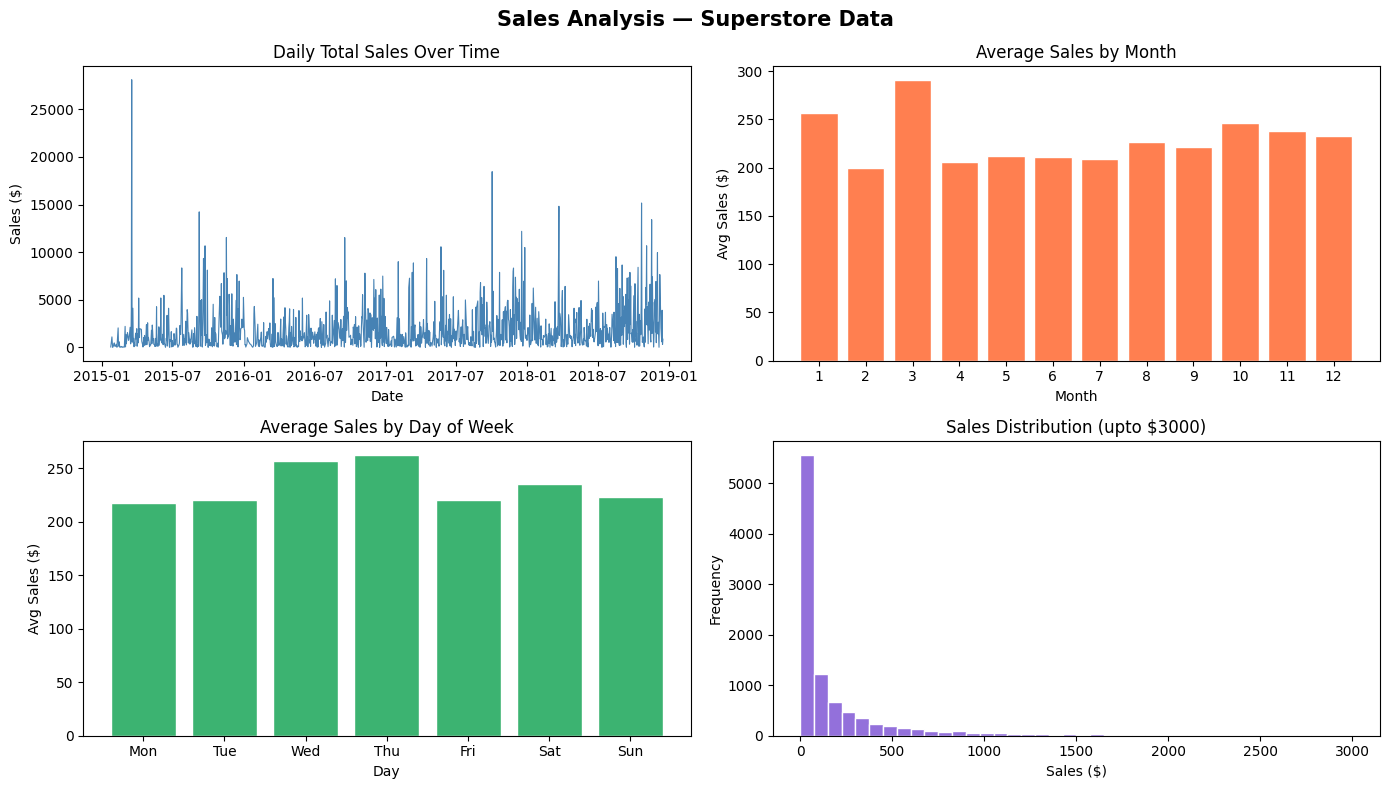


eda_graphs.png saved


In [6]:
# ── STEP 3: EDA GRAPHS ───────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Sales Analysis — Superstore Data', fontsize=15, fontweight='bold')

axes[0,0].plot(dd['date'], dd['sales'], color='steelblue', linewidth=0.8)
axes[0,0].set(title='Daily Total Sales Over Time', xlabel='Date', ylabel='Sales ($)')

monthly = df.groupby('Month')['sales'].mean()
axes[0,1].bar(monthly.index, monthly.values, color='coral', edgecolor='white')
axes[0,1].set(title='Average Sales by Month', xlabel='Month', ylabel='Avg Sales ($)')
axes[0,1].set_xticks(range(1, 13))

dow = df.groupby('DayOfWeek')['sales'].mean()
axes[1,0].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow.values,
               color='mediumseagreen', edgecolor='white')
axes[1,0].set(title='Average Sales by Day of Week', xlabel='Day', ylabel='Avg Sales ($)')

axes[1,1].hist(df[df['sales'] <= 3000]['sales'], bins=40, color='mediumpurple', edgecolor='white')
axes[1,1].set(title='Sales Distribution (upto $3000)', xlabel='Sales ($)', ylabel='Frequency')

plt.tight_layout()
plt.savefig('eda_graphs.png', dpi=150)
plt.show()
print("\neda_graphs.png saved")


Yearly Total Sales:
Year
2015    479856.2081
2016    454315.9054
2017    597225.4900
2018    721209.8092
Name: sales, dtype: float64


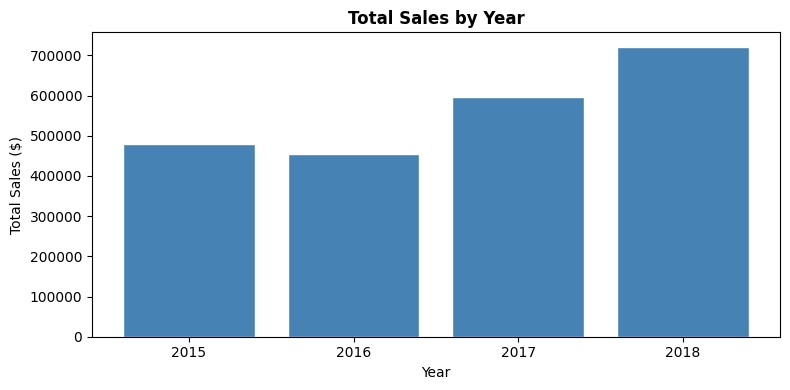

yearly_sales.png saved

Sales by Category:
Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: sales, dtype: float64

Top 10 Sub-Categories:
Sub-Category
Phones         326487.6980
Chairs         322107.5310
Storage        217779.1020
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    163881.6900
Copiers        146248.0940
Bookcases      109408.2987
Appliances     104075.4630
Name: sales, dtype: float64


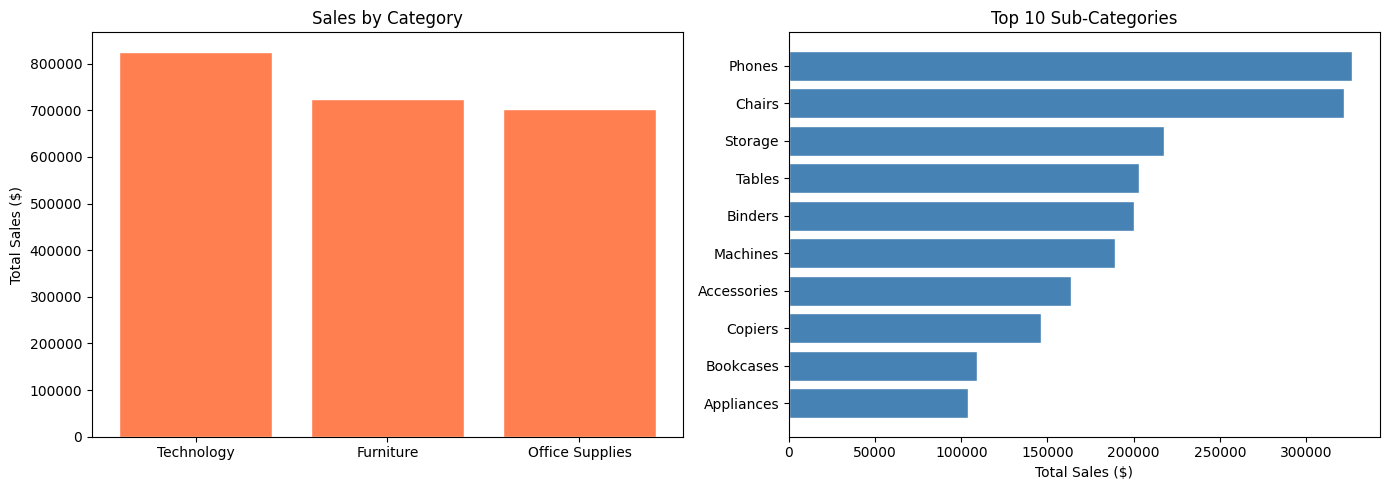

category_graphs.png saved


In [7]:
# ── STEP 4: YEARLY + CATEGORY GRAPHS ─────────────────────────────────────────

yearly = df.groupby('Year')['sales'].sum()
print(f"\nYearly Total Sales:\n{yearly}")

plt.figure(figsize=(8, 4))
plt.bar(yearly.index.astype(str), yearly.values, color='steelblue', edgecolor='white')
plt.title('Total Sales by Year', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('yearly_sales.png', dpi=150)
plt.show()
print("yearly_sales.png saved")

cat_s = df.groupby('Category')['sales'].sum().sort_values(ascending=False)
sub_s = df.groupby('Sub-Category')['sales'].sum().sort_values(ascending=False).head(10)

print(f"\nSales by Category:\n{cat_s}")
print(f"\nTop 10 Sub-Categories:\n{sub_s}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(cat_s.index, cat_s.values, color='coral', edgecolor='white')
axes[0].set(title='Sales by Category', ylabel='Total Sales ($)')
axes[1].barh(sub_s.index[::-1], sub_s.values[::-1], color='steelblue', edgecolor='white')
axes[1].set(title='Top 10 Sub-Categories', xlabel='Total Sales ($)')
plt.tight_layout()
plt.savefig('category_graphs.png', dpi=150)
plt.show()
print("category_graphs.png saved")


Monthly Sales with Moving Average:
   Year  Month       sales           MA3
0  2015      1  14205.7070           NaN
1  2015      2   4519.8920           NaN
2  2015      3  55205.7970  24643.798667
3  2015      4  27906.8550  29210.848000
4  2015      5  23644.3030  35585.651667
5  2015      6  34322.9356  28624.697867
6  2015      7  33781.5430  30582.927200
7  2015      8  27117.5365  31740.671700
8  2015      9  81623.5268  47507.535433
9  2015     10  31453.3930  46731.485433


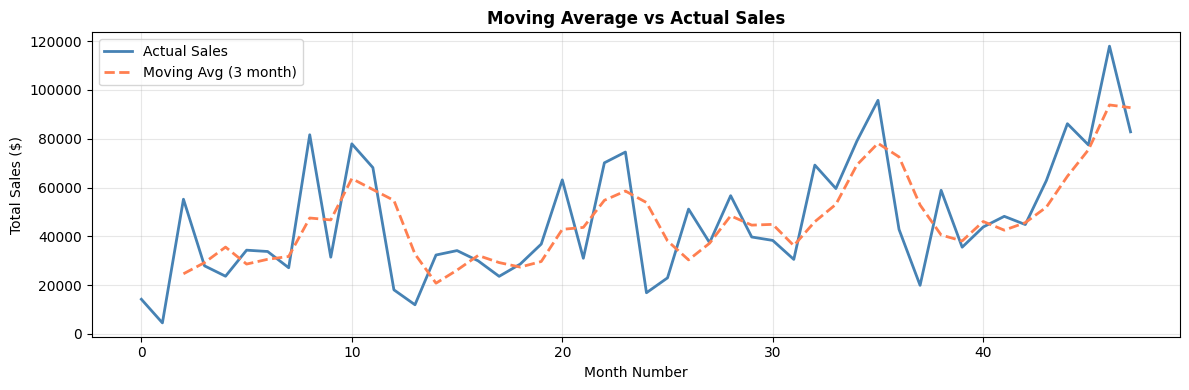

moving_avg.png saved


In [8]:
# ── STEP 5: MOVING AVERAGE ───────────────────────────────────────────────────

dm = df.groupby(['Year','Month'])['sales'].sum().reset_index()
dm = dm.sort_values(['Year','Month']).reset_index(drop=True)
dm['MA3'] = dm['sales'].rolling(3).mean()

print(f"\nMonthly Sales with Moving Average:\n{dm[['Year','Month','sales','MA3']].head(10)}")

plt.figure(figsize=(12, 4))
plt.plot(dm['sales'].values, label='Actual Sales', color='steelblue', linewidth=2)
plt.plot(dm['MA3'].values, label='Moving Avg (3 month)', color='coral', linewidth=2, linestyle='--')
plt.title('Moving Average vs Actual Sales', fontweight='bold')
plt.xlabel('Month Number')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('moving_avg.png', dpi=150)
plt.show()
print("moving_avg.png saved")


Monthly Seasonality Pattern:
  Jan: $27  (above average)
  Feb: $-29  (below average)
  Mar: $61  (above average)
  Apr: $-23  (below average)
  May: $-17  (below average)
  Jun: $-18  (below average)
  Jul: $-20  (below average)
  Aug: $-2  (below average)
  Sep: $-8  (below average)
  Oct: $17  (above average)
  Nov: $9  (above average)
  Dec: $3  (above average)


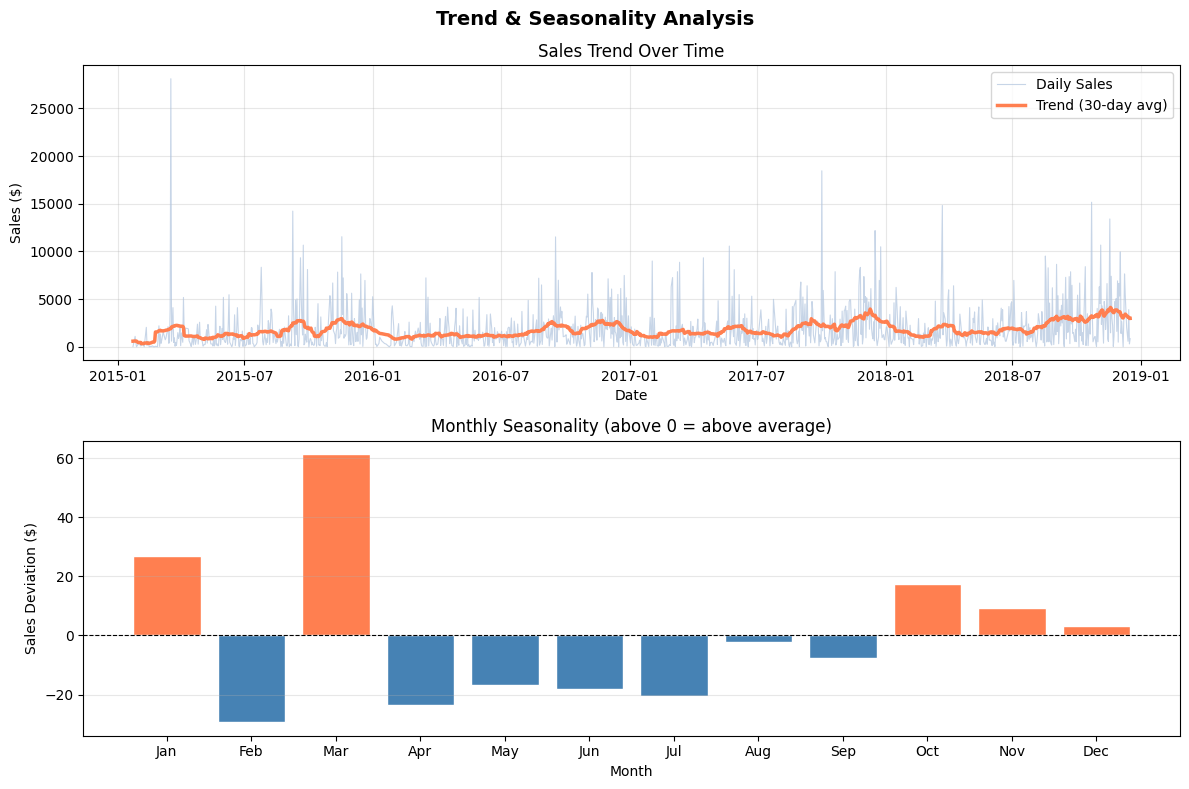

trend_seasonality.png saved


In [9]:
# ── STEP 6: TREND & SEASONALITY ──────────────────────────────────────────────

sea   = df.groupby('Month')['sales'].mean()
sea_c = sea - sea.mean()

print(f"\nMonthly Seasonality Pattern:")
months_full = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for m, v in zip(months_full, sea_c.values):
    direction = "above average" if v > 0 else "below average"
    print(f"  {m}: ${v:,.0f}  ({direction})")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Trend & Seasonality Analysis', fontsize=14, fontweight='bold')

axes[0].plot(dd['date'], dd['sales'], color='lightsteelblue', linewidth=0.8,
             alpha=0.7, label='Daily Sales')
axes[0].plot(dd['date'], dd['Trend'], color='coral', linewidth=2.5,
             label='Trend (30-day avg)')
axes[0].set(title='Sales Trend Over Time', xlabel='Date', ylabel='Sales ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(months_full, sea_c.values,
            color=['coral' if v > 0 else 'steelblue' for v in sea_c.values],
            edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set(title='Monthly Seasonality (above 0 = above average)',
            xlabel='Month', ylabel='Sales Deviation ($)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('trend_seasonality.png', dpi=150)
plt.show()
print("trend_seasonality.png saved")

In [10]:
# ── STEP 7: LINEAR REGRESSION — TEMPORAL SPLIT ───────────────────────────────

feats     = ['Month', 'Year', 'DayOfWeek', 'DayOfYear', 'Quarter', 'Lag1', 'Lag7', 'MA7']
split_idx = int(len(dd) * 0.8)

X_train = dd[feats].iloc[:split_idx]
X_test  = dd[feats].iloc[split_idx:]
y_train = dd['sales'].iloc[:split_idx]
y_test  = dd['sales'].iloc[split_idx:]

print(f"\nTrain: {len(X_train)} rows ({dd['date'].iloc[0].date()} to {dd['date'].iloc[split_idx-1].date()})")
print(f"Test:  {len(X_test)} rows  ({dd['date'].iloc[split_idx].date()} to {dd['date'].iloc[-1].date()})")

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"\nFirst 5 predictions : {y_pred[:5].astype(int)}")
print(f"Actual values       : {y_test.values[:5].astype(int)}")


Train: 960 rows (2015-01-23 to 2018-03-28)
Test:  240 rows  (2018-03-29 to 2018-12-16)

First 5 predictions : [4143 2589 2523 2621 2079]
Actual values       : [  81  656 4981 5972  822]


In [11]:
# ── STEP 8: ERROR METRICS ────────────────────────────────────────────────────

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('\n' + '=' * 45)
print('      Model Performance Report')
print('=' * 45)
print(f'  MAE  (Mean Absolute Error) : ${mae:,.2f}')
print(f'  MSE  (Mean Squared Error)  : ${mse:,.2f}')
print(f'  RMSE (Root Mean Sq Error)  : ${rmse:,.2f}')
print(f'  R²   (R-squared)           : {r2:.4f}')
print(f'  MAPE (Mean Abs % Error)    : {mape:.2f}%')
print('=' * 45)
print(f'  Model is off by ${mae:,.0f} on average')
print('=' * 45)


      Model Performance Report
  MAE  (Mean Absolute Error) : $1,652.12
  MSE  (Mean Squared Error)  : $4,887,384.76
  RMSE (Root Mean Sq Error)  : $2,210.74
  R²   (R-squared)           : 0.2001
  MAPE (Mean Abs % Error)    : 758.08%
  Model is off by $1,652 on average


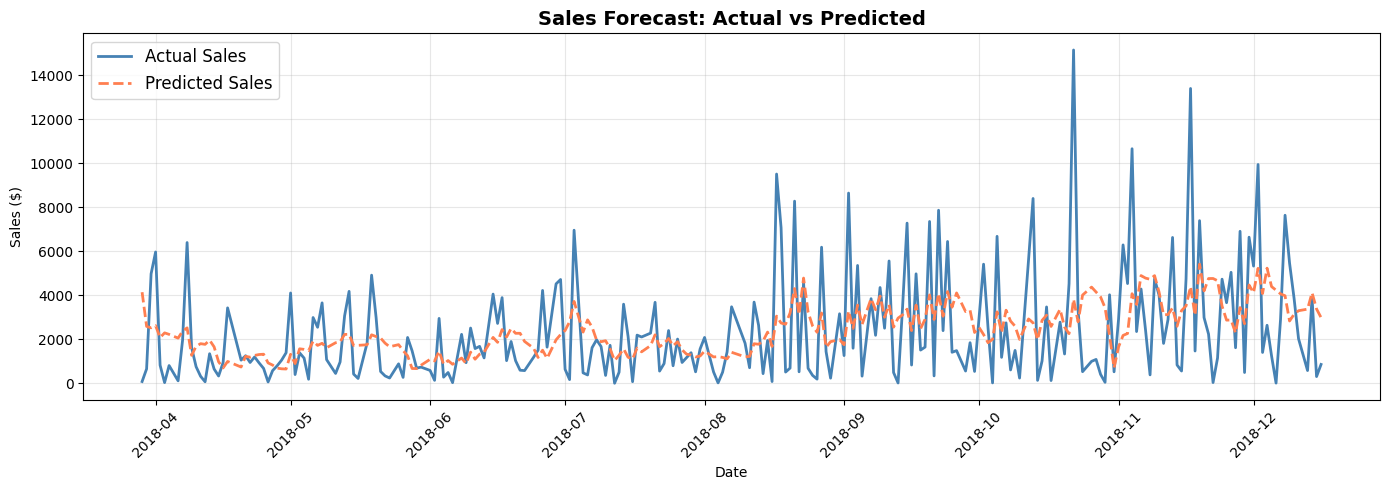

actual_vs_predicted.png saved


In [12]:
# ── STEP 9: ACTUAL VS PREDICTED ──────────────────────────────────────────────

test_dates = dd['date'].iloc[split_idx:].reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test.values, label='Actual Sales', color='steelblue', linewidth=2)
plt.plot(test_dates, y_pred, label='Predicted Sales', color='coral', linewidth=2, linestyle='--')
plt.title('Sales Forecast: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()
print("actual_vs_predicted.png saved")


Next 30 Days Sales Forecast:
Date            Predicted Sales
--------------------------------
2018-12-17      $       40.39
2018-12-18      $      156.95
2018-12-19      $    4,354.83
2018-12-20      $      702.31
2018-12-21      $    3,377.37
2018-12-22      $    1,294.58
2018-12-23      $      348.75
2018-12-24      $      110.68
2018-12-25      $    7,033.99
2018-12-26      $    8,776.41
2018-12-27      $    9,162.72
2018-12-28      $    1,436.35
2018-12-29      $    3,771.21
2018-12-30      $      330.65
2018-12-31      $    1,067.16
2019-01-01      $    8,102.00
2019-01-02      $    5,153.08
2019-01-03      $    5,796.80
2019-01-04      $    1,038.71
2019-01-05      $    5,652.83
2019-01-06      $    3,145.97
2019-01-07      $    5,180.00
2019-01-08      $    2,041.03
2019-01-09      $    3,798.55
2019-01-10      $    6,712.48
2019-01-11      $    2,061.45
2019-01-12      $    1,313.50
2019-01-13      $      911.52
2019-01-14      $    2,900.80
2019-01-15      $      691.40

Tota

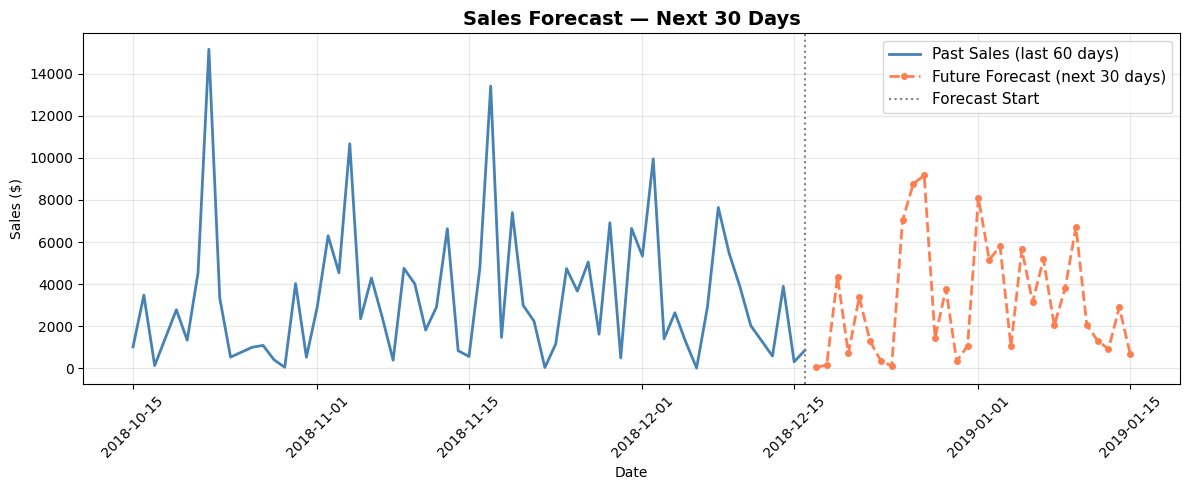

future_forecast.png saved

  PROJECT COMPLETE! 7 graphs saved:
  1. eda_graphs.png
  2. yearly_sales.png
  3. category_graphs.png
  4. moving_avg.png
  5. trend_seasonality.png
  6. actual_vs_predicted.png
  7. future_forecast.png


In [13]:
# ── STEP 10: FUTURE FORECAST — Next 30 Days ──────────────────────────────────

last_date    = dd['date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

same_period = dd[
    (dd['date'] >= last_date - pd.Timedelta(days=395)) &
    (dd['date'] <= last_date - pd.Timedelta(days=335))
]['sales'].values

if len(same_period) >= 30:
    future_pred = same_period[:30] * 1.1
else:
    base  = dd['sales'].iloc[-30:].mean()
    noise = np.random.normal(0, dd['sales'].iloc[-30:].std() * 0.3, 30)
    future_pred = np.clip(base + noise, 0, None)

future_pred = np.clip(future_pred, 0, None)

print(f"\nNext 30 Days Sales Forecast:")
print(f"{'Date':<15} {'Predicted Sales':>15}")
print("-" * 32)
for date, pred in zip(future_dates, future_pred):
    print(f"{str(date.date()):<15} ${pred:>12,.2f}")

print(f"\nTotal Forecasted Sales (next 30 days): ${future_pred.sum():,.2f}")
print(f"Average Daily Forecast               : ${future_pred.mean():,.2f}")

plt.figure(figsize=(12, 5))
last_60 = dd.tail(60)
plt.plot(last_60['date'], last_60['sales'],
         label='Past Sales (last 60 days)', color='steelblue', linewidth=2)
plt.plot(future_dates, future_pred,
         label='Future Forecast (next 30 days)', color='coral',
         linewidth=2, linestyle='--', marker='o', markersize=4)
plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
plt.title('Sales Forecast — Next 30 Days', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150)
plt.show()
print("future_forecast.png saved")

print('\n' + '=' * 45)
print('  PROJECT COMPLETE! 7 graphs saved:')
print('  1. eda_graphs.png')
print('  2. yearly_sales.png')
print('  3. category_graphs.png')
print('  4. moving_avg.png')
print('  5. trend_seasonality.png')
print('  6. actual_vs_predicted.png')
print('  7. future_forecast.png')
print('=' * 45)